In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
from sklearn.linear_model   import LinearRegression
from sklearn.preprocessing  import LabelEncoder
from sklearn.metrics        import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')

# ── UPDATE THESE PATHS ────────────────────────────────────────────────────────
RAW_DATA_PATH  = r"C:\Users\Rishit\Desktop\O2R-Order-prediction\data\Jan - May '26 Data.csv"
ENCODER_PATH   = r"C:\Users\Rishit\Desktop\O2R-Order-prediction\processed\label_encoders.pkl"
PROFILE_PATH   = r"C:\Users\Rishit\Desktop\O2R-Order-prediction\processed\retailer_profiles.parquet"
MODEL_PATH     = r"C:\Users\Rishit\Desktop\O2R-Order-prediction\models\xgboost_next_order_model.pkl"
OUTPUTS_DIR    = r"C:\Users\Rishit\Desktop\O2R-Order-prediction\outputs"
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
print('Setup complete.')

Setup complete.


In [2]:
df = pd.read_csv(RAW_DATA_PATH)
df['createdAt'] = pd.to_datetime(df['createdAt'], dayfirst=True)

confirmed = df[df['orderStatus'].isin(['Delivered','PartiallyDelivered'])]
orders = confirmed.drop_duplicates(subset='orderNumber')[[
    'orderNumber','customerId','createdAt','hubName','shopType','retailerType','orderSource'
]].copy()
orders = orders.sort_values(['customerId','createdAt'])

with open(ENCODER_PATH, 'rb') as f:
    label_encoders = pickle.load(f)
retailer_profile = pd.read_parquet(PROFILE_PATH)

print(f'Orders loaded   : {len(orders):,}')
print(f'Retailers       : {orders["customerId"].nunique():,}')
print(f'History end     : {orders["createdAt"].max().date()}')

Orders loaded   : 177,340
Retailers       : 8,640
History end     : 2026-05-31


In [3]:
orders['next_order_date'] = orders.groupby('customerId')['createdAt'].shift(-1)
orders['days_until_next'] = (orders['next_order_date'] - orders['createdAt']).dt.days

reg_df = orders[orders['days_until_next'].notna()].copy()
# Remove churned retailers (gap > 60 days)
reg_df = reg_df[(reg_df['days_until_next'] >= 0) & (reg_df['days_until_next'] <= 60)]

print(f'Regression training rows : {len(reg_df):,}')
print()
print('Target (days_until_next) distribution:')
print(reg_df['days_until_next'].describe().to_string())

Regression training rows : 168,161

Target (days_until_next) distribution:
count    168161.000000
mean          4.344967
std           6.297356
min           0.000000
25%           1.000000
50%           2.000000
75%           5.000000
max          60.000000


In [4]:
# Compute gap stats per retailer from full history
gap_stats = orders.groupby('customerId')['days_until_next'].agg(
    avg_gap    = 'mean',
    std_gap    = 'std',
    median_gap = 'median',
    min_gap    = 'min',
    max_gap    = 'max',
    count      = 'count'
).reset_index()
gap_stats = gap_stats.fillna({'avg_gap':7,'std_gap':0,'median_gap':7,'min_gap':0,'max_gap':0})

# App ratio
app_ratio = (
    orders.groupby('customerId')
    .apply(lambda x: (x['orderSource'] == 'App').mean())
    .reset_index()
)
app_ratio.columns = ['customerId','app_order_ratio']

reg_df = reg_df\
    .merge(gap_stats, on='customerId', how='left')\
    .merge(app_ratio, on='customerId', how='left')\
    .merge(retailer_profile[['customerId','tenure_days']], on='customerId', how='left')

# Temporal
reg_df['day_of_week']  = reg_df['createdAt'].dt.dayofweek
reg_df['month']        = reg_df['createdAt'].dt.month
reg_df['is_weekend']   = (reg_df['createdAt'].dt.dayofweek >= 5).astype(int)
reg_df['day_of_month'] = reg_df['createdAt'].dt.day

# Encode categoricals
for col in ['hubName','shopType','retailerType']:
    le = label_encoders[col]
    known = set(le.classes_)
    reg_df[col] = reg_df[col].apply(lambda x: x if str(x) in known else le.classes_[0])
    reg_df[col+'_enc'] = le.transform(reg_df[col].fillna('Unknown').astype(str))

print('Features engineered.')
print(f'Dataset shape: {reg_df.shape}')

Features engineered.
Dataset shape: (168161, 24)


In [5]:
REG_FEATURES = [
    'avg_gap','std_gap','median_gap','min_gap','max_gap','count',
    'app_order_ratio','tenure_days',
    'day_of_week','month','is_weekend','day_of_month',
    'hubName_enc','shopType_enc','retailerType_enc'
]
TARGET = 'days_until_next'

# Val: orders placed in May (predict gap from May to June)
train_r = reg_df[reg_df['createdAt'] < '2026-05-01']
val_r   = reg_df[reg_df['createdAt'] >= '2026-05-01']

X_tr = np.nan_to_num(train_r[REG_FEATURES].values, nan=0.0)
y_tr = train_r[TARGET].values
X_vl = np.nan_to_num(val_r[REG_FEATURES].values,   nan=0.0)
y_vl = val_r[TARGET].values

print(f'Train : {len(X_tr):,} rows')
print(f'Val   : {len(X_vl):,} rows')

# Baseline
print('\nTraining Linear Regression baseline...')
lr = LinearRegression()
lr.fit(X_tr, y_tr)
lr_p = np.clip(lr.predict(X_vl), 0, 60)
print(f'LR — MAE: {mean_absolute_error(y_vl, lr_p):.2f} days | R2: {r2_score(y_vl, lr_p):.4f}')

# XGBoost
print('\nTraining XGBoost Regressor...')
xgb_reg = xgb.XGBRegressor(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, tree_method='hist'
)
xgb_reg.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=50)
xgb_p = np.clip(xgb_reg.predict(X_vl), 0, 60)

mae  = mean_absolute_error(y_vl, xgb_p)
rmse = np.sqrt(mean_squared_error(y_vl, xgb_p))
r2   = r2_score(y_vl, xgb_p)

print(f'\nXGBoost — MAE: {mae:.2f} days | RMSE: {rmse:.2f} | R2: {r2:.4f}')

Train : 138,676 rows
Val   : 29,485 rows

Training Linear Regression baseline...
LR — MAE: 2.04 days | R2: 0.0472

Training XGBoost Regressor...
[0]	validation_0-rmse:3.48151
[50]	validation_0-rmse:3.05324
[100]	validation_0-rmse:3.15514
[150]	validation_0-rmse:3.20645
[200]	validation_0-rmse:3.22850
[250]	validation_0-rmse:3.26041
[300]	validation_0-rmse:3.29025
[350]	validation_0-rmse:3.31565
[399]	validation_0-rmse:3.33752

XGBoost — MAE: 2.10 days | RMSE: 3.34 | R2: -0.0848


Predictions within 1 day  : 42.1%
Predictions within 2 days : 66.6%
Predictions within 3 days : 79.0%


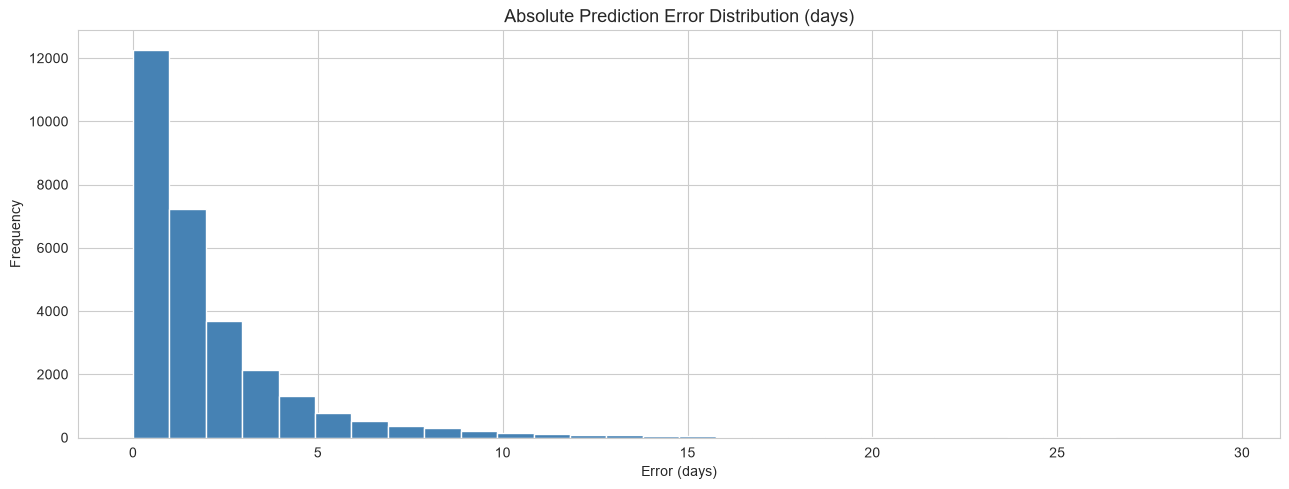

In [6]:
# Error distribution
errors = np.abs(xgb_p - y_vl)
print(f'Predictions within 1 day  : {(errors<=1).mean()*100:.1f}%')
print(f'Predictions within 2 days : {(errors<=2).mean()*100:.1f}%')
print(f'Predictions within 3 days : {(errors<=3).mean()*100:.1f}%')

plt.figure(figsize=(13,5))
plt.hist(errors[errors<=30], bins=30, color='steelblue', edgecolor='white')
plt.title('Absolute Prediction Error Distribution (days)', fontsize=13)
plt.xlabel('Error (days)'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

In [7]:
print('Retraining on full Jan–May data...')
X_all = np.nan_to_num(reg_df[REG_FEATURES].values, nan=0.0)
y_all = reg_df[TARGET].values

xgb_final_reg = xgb.XGBRegressor(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, tree_method='hist'
)
xgb_final_reg.fit(X_all, y_all, verbose=50)
print('Final regression model trained.')

Retraining on full Jan–May data...
Final regression model trained.


In [8]:
# Use each retailer's last confirmed order as the reference point
last_orders = orders.sort_values('createdAt').groupby('customerId').last().reset_index()

# Merge features
pred_df = last_orders[['customerId','createdAt','hubName','shopType','retailerType','orderSource']]\
    .merge(gap_stats, on='customerId', how='left')\
    .merge(app_ratio, on='customerId', how='left')\
    .merge(retailer_profile[['customerId','tenure_days']], on='customerId', how='left')

pred_df['day_of_week']  = pred_df['createdAt'].dt.dayofweek
pred_df['month']        = pred_df['createdAt'].dt.month
pred_df['is_weekend']   = (pred_df['createdAt'].dt.dayofweek >= 5).astype(int)
pred_df['day_of_month'] = pred_df['createdAt'].dt.day

for col in ['hubName','shopType','retailerType']:
    le = label_encoders[col]
    known = set(le.classes_)
    pred_df[col] = pred_df[col].apply(lambda x: x if str(x) in known else le.classes_[0])
    pred_df[col+'_enc'] = le.transform(pred_df[col].fillna('Unknown').astype(str))

pred_df = pred_df.fillna({'avg_gap':7,'std_gap':0,'median_gap':7,
                           'min_gap':0,'max_gap':0,'count':1,
                           'app_order_ratio':0.5,'tenure_days':0})

X_pred = np.nan_to_num(pred_df[REG_FEATURES].values, nan=0.0)
pred_df['predicted_days_until_next'] = np.clip(xgb_final_reg.predict(X_pred), 1, 60).round(1)

REFERENCE_DATE = pd.Timestamp('2026-05-31')
pred_df['predicted_next_order_date'] = (
    REFERENCE_DATE +
    pd.to_timedelta(pred_df['predicted_days_until_next'], unit='D')
).dt.date

pred_df['last_order_date'] = pred_df['createdAt'].dt.date

schedule = pred_df[[
    'customerId','hubName','shopType','retailerType',
    'last_order_date','avg_gap','predicted_days_until_next','predicted_next_order_date'
]].rename(columns={'avg_gap':'historical_avg_gap_days'})

schedule = schedule.sort_values('predicted_next_order_date')

print(f'Schedule built for {len(schedule):,} retailers')
print()
print('=== FIRST 20 RETAILERS EXPECTED TO ORDER IN JUNE ===')
print(schedule.head(20).to_string(index=False))

Schedule built for 8,640 retailers

=== FIRST 20 RETAILERS EXPECTED TO ORDER IN JUNE ===
customerId                       hubName  shopType retailerType last_order_date  historical_avg_gap_days  predicted_days_until_next predicted_next_order_date
   USR-100      Crossline Events (Noida)    Paan A         HVLF      2026-05-27                12.083333                        1.5                2026-06-01
USR-169897 Cross Line Events (Ghaziabad)    Paan B         HVHF      2026-05-30                 2.508475                        1.9                2026-06-01
 USR-91230           Instant Foods (SED) General A         HVHF      2026-05-29                 2.046154                        1.4                2026-06-01
 USR-13364      Crossline Events (Noida)    Paan B         HVHF      2026-05-30                 1.850000                        1.7                2026-06-01
 USR-91234           Instant Foods (SED) General A         HVLF      2026-05-28                16.222222                 

In [9]:
# Save regression model
with open(MODEL_PATH, 'wb') as f:
    pickle.dump({'model': xgb_final_reg, 'feature_cols': REG_FEATURES}, f)
print(f'Regression model saved → {MODEL_PATH}')

# Save schedule
out_path = os.path.join(OUTPUTS_DIR, 'next_order_prediction_june2026.csv')
schedule.to_csv(out_path, index=False)
print(f'Schedule saved → {out_path}')

print()
print('=== PHASE 2 COMPLETE ===')
print(f'Model predicts next order date with ~{mae:.1f} day average error')

# Daily predicted order volume for June
daily_pred = schedule.groupby('predicted_next_order_date').size().reset_index()
daily_pred.columns = ['Date','Predicted Orders']
print('\n=== PREDICTED ORDER VOLUME PER DAY IN JUNE ===')
print(daily_pred.to_string(index=False))

Regression model saved → C:\Users\Rishit\Desktop\O2R-Order-prediction\models\xgboost_next_order_model.pkl
Schedule saved → C:\Users\Rishit\Desktop\O2R-Order-prediction\outputs\next_order_prediction_june2026.csv

=== PHASE 2 COMPLETE ===
Model predicts next order date with ~2.1 day average error

=== PREDICTED ORDER VOLUME PER DAY IN JUNE ===
      Date  Predicted Orders
2026-06-01              1339
2026-06-02              1353
2026-06-03              1056
2026-06-04               750
2026-06-05               465
2026-06-06               933
2026-06-07               814
2026-06-08               251
2026-06-09               186
2026-06-10               145
2026-06-11               136
2026-06-12               128
2026-06-13               108
2026-06-14                76
2026-06-15                74
2026-06-16                61
2026-06-17                49
2026-06-18                43
2026-06-19                57
2026-06-20                39
2026-06-21                52
2026-06-22        

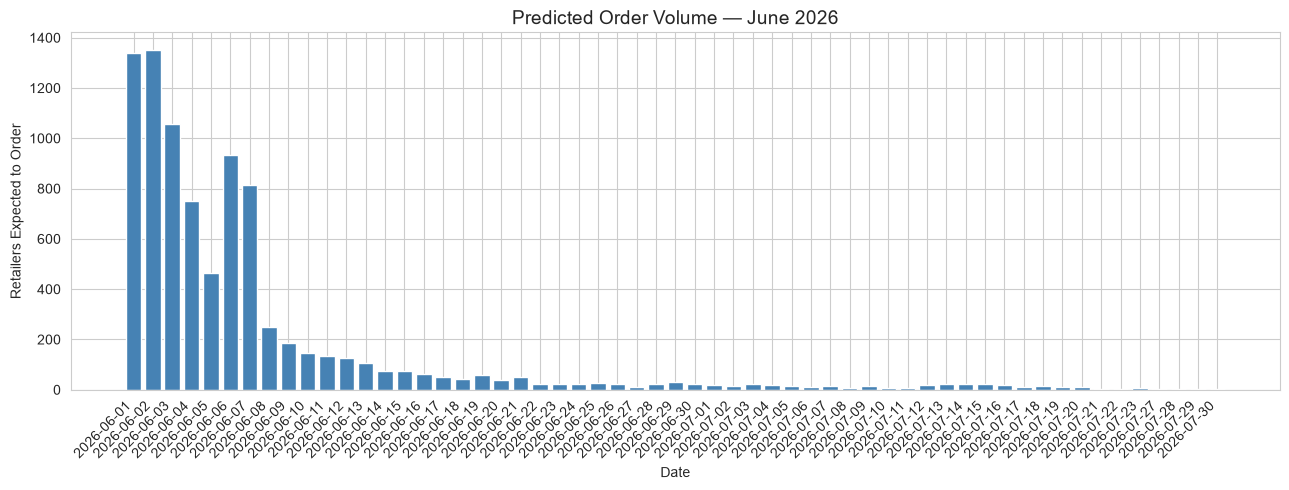

In [10]:
# Visualise predicted order volume across June
plt.figure(figsize=(13,5))
plt.bar(daily_pred['Date'].astype(str), daily_pred['Predicted Orders'],
        color='steelblue', edgecolor='white')
plt.title('Predicted Order Volume — June 2026', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Retailers Expected to Order')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()